# Pre-MS stars

This are used to prepare and launch the simulations related to the paper on detectability of p-mode oscillations in pre-main sequence stars.

- Author: Nicholas Jannsen
- Last check: 30-08-2025
- Commit: b78dfc3775580970209e409a5d83af572a7d9c94 

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# PlatoSim libraries
import platosim.plot      as pt
import platosim.mocka     as mk
import platosim.utilities as ut
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [3]:
path = Path(os.getenv('PLATO_WORKDIR')) / 'pre-ms'
idir = path / 'input'
sdir = path / 'simulations' 

---
## 1. Stellar catalogue
---

In [4]:
# Load PLATO-CS catalogue
df = pd.read_feather(path / '../PlatoCS/input/starcat_PlatoCS_NCAM_LOPS2.ftr')

In [5]:
# Load Pre-MS catalogue
dt = pd.read_csv(path / 'input/plato_sample.txt', sep=' ', comment='#',
                 names=['ID', 'gaiaDR3', 'Pmag', 'Gmag', 'ra', 'dec'])
dt.head()

,ID,gaiaDR3,Pmag,Gmag,ra,dec
0,1,2885659097345755648,14.841428,15.018138,94.514026,-34.544374
1,2,2886290079581074432,15.142609,15.319207,93.342170,-35.022312
2,3,2890046080021476352,14.823780,14.999045,91.413240,-32.674862
3,4,2895540751943528960,16.155236,16.329124,97.784416,-29.021455
4,5,2895546146422412800,15.847063,16.032137,97.996331,-28.911655


<IPython.core.display.Javascript object>


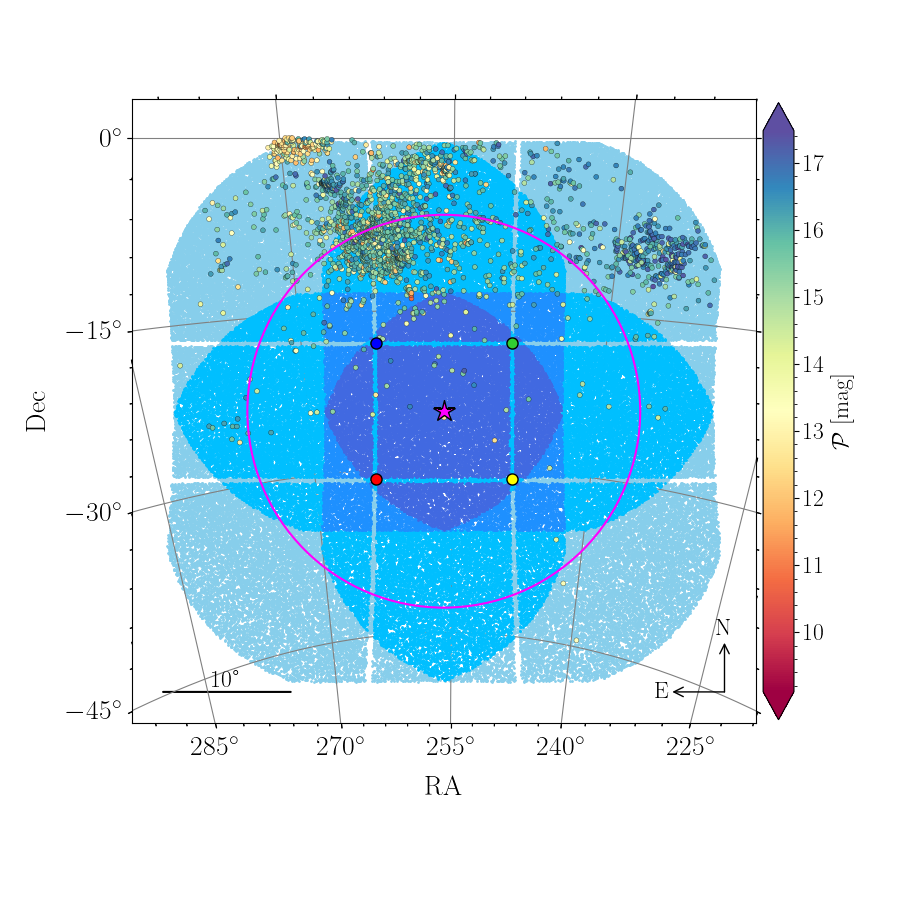

In [36]:
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', fovSize=30,
                          raStars=dt.ra, decStars=dt.dec, c=dt.Pmag,
                          ncamStars=True, showGroups=True, showFcamFOV=True,
                          clabel=r'$\mathcal{P}$ [mag]', s=50, lw=0.2, figsize=(9,9))
# fig.savefig(f'{pdir}/starcat_sky_EBs.png', bbox_inches='tight', dpi=200)

In [19]:
# Create target catalogue
dt.reset_index(drop=True, inplace=True)
dt.to_feather(idir / 'starcat_PreMS_targets.ftr')

In [20]:
# Create contaminant catalogue
dc = ut.getContaminants(dt, df, column='gaiaDR3')
dc.to_feather(idir / 'starcat_PreMS_contaminants.ftr')

100%|██████████████████████████████████████████████████| 2452/2452 [04:30<00:00,


---
## 2. Post-processing
---

We ran a few test simulations saving the default photometry to the HDF5 file:
```
platonium 1 2 1 1 --project pre-ms --varsource_test.txt 
```

In [9]:
# Load file to test detrending with
filename = f"{sdir}/test/hdf5/000000001/000000001_Ncam2.1_Q1.hdf5"

# Load a single mission quarter light curve
lc = LightCurve(filename, mode="single")
dt = lc.star()
dt

,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,1,2.885659e+18,94.514026,-34.544374,14.841428,2,1,1,4,858.602157,2972.11676,7.70238,28.981898,16.754839,3,0.006829


<IPython.core.display.Javascript object>


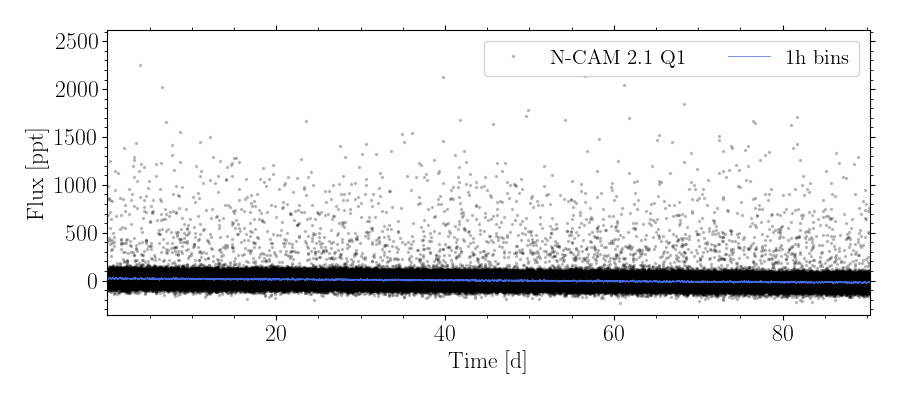

In [10]:
# Show a quarter light curve
lc.plot(flux_unit='ppt', median_filter=1, input_model=False, figsize=(9,4));

### 2.1. Test detrending

<IPython.core.display.Javascript object>


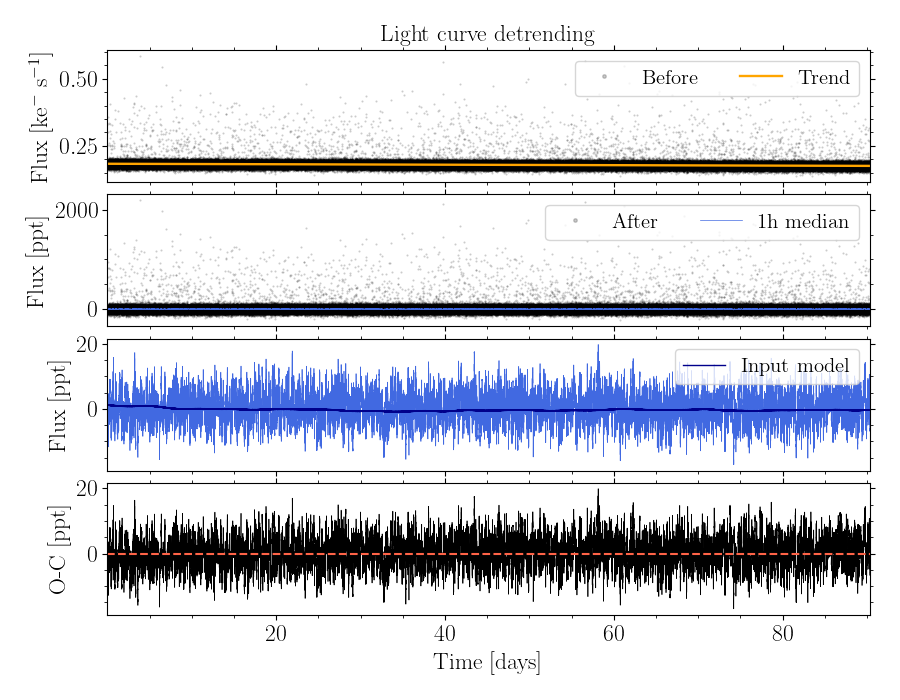

In [11]:
# Generate plot to save
df = lc.detrend(model='poly', replace=True, plot=True)

### 2.2. Test outlier rejection

<IPython.core.display.Javascript object>


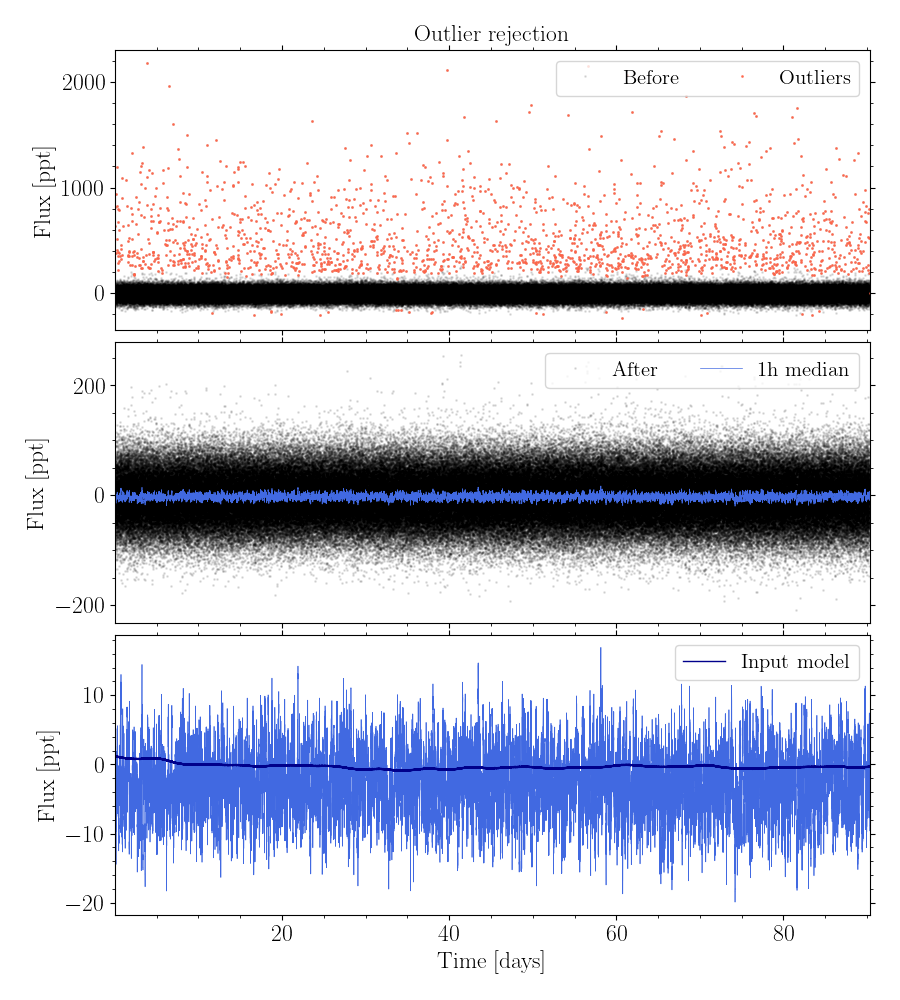

In [14]:
# Remove outliers (due to photon noise and cosmic ray hits)
df = lc.clip(model='wotan', sigma_lower=3, sigma_upper=3, flux_unit='ppt', plot=True, replace=True)

### 2.3. Test error estimation

<IPython.core.display.Javascript object>


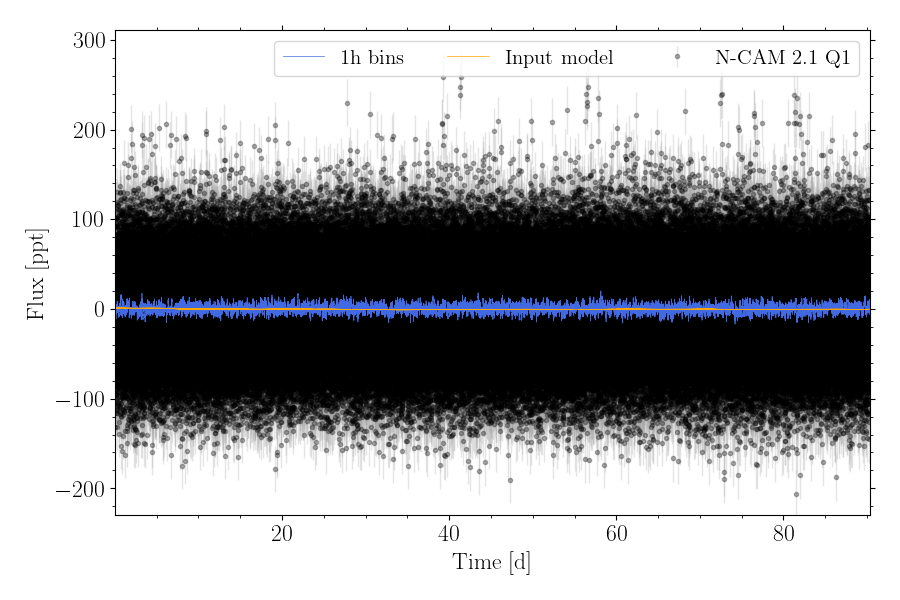

In [44]:
df = lc.flux_error(flux_unit='ppt', plot=True)

---
## 3. Analysis of simulations
---

In [45]:
# Initialise light curve object
star = '000000001'
fdir = sdir / 'test/ftr' / star
lcs = LightCurve(fdir, mode="multi")

In [46]:
# Create table with simulation statistics
df = lcs.stat_sim_table(ofile=fdir / f'lc_{star}.tab', clean=True)
df.head()

[Warning]: Remove your "ofile" to use "clean" (if ".table" files still exists)


,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,1,2.885659e+18,94.514026,-34.544374,14.841428,1,1,2,3,858.281052,2971.845771,7.702682,16.749059,-28.986776,3,0.002125
1,1,2.885659e+18,94.514026,-34.544374,14.841428,1,1,3,1,1572.031236,2376.796389,11.312664,-29.596562,39.697665,3,0.010706
2,1,2.885659e+18,94.514026,-34.544374,14.841428,1,1,6,3,858.498991,2971.966790,7.702700,16.752982,-28.984598,3,0.003174
3,1,2.885659e+18,94.514026,-34.544374,14.841428,1,1,7,1,1571.971656,2376.549462,11.313314,-29.595490,39.702110,3,0.006418
4,1,2.885659e+18,94.514026,-34.544374,14.841428,1,2,2,3,868.824595,2984.312832,7.680356,16.938843,-28.762369,3,0.011005


<IPython.core.display.Javascript object>


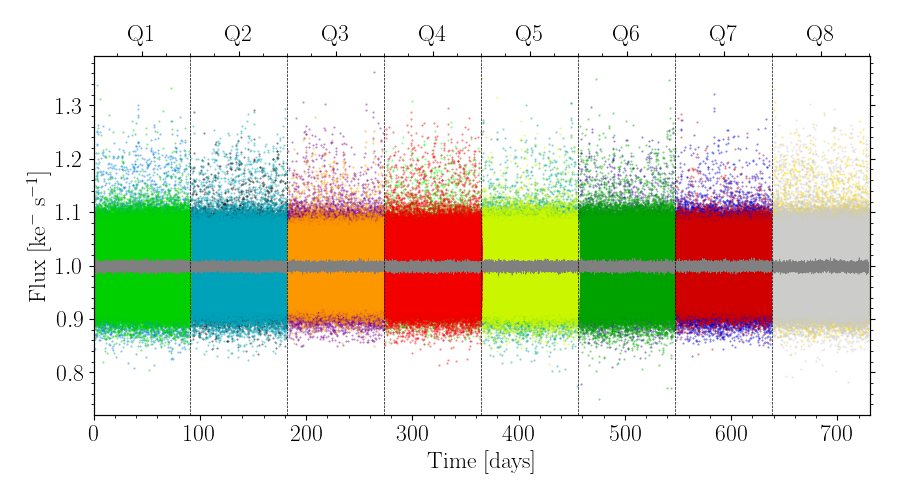

In [6]:
# Show all light curves
fig, ax = lcs.plot_multi(suffix='ftr', group=False, camera=1, quarter=False, 
                         flux_median=144, alpha=0.5, figsize=(9,5))

In [67]:
# Post-processing into final light curve
lc = lcs.merge(suffix='ftr',
               flux_group_mean=True,
               binsize=25,
               clip_sigma=3,
               flux_offset=True,
               flux_error=True,
               ofile= fdir / f'lc_{star}.ftr'
              )

Processing star ID 000000001
-------------------------------------------------------
Merging 96 light curves


100%|██████████████████████████████████████████████████| 96/96 [00:07<00:00, 12.07it/s]              


Sorting data after timings
Averaging data from same camera group
Binning data per 25s
Removing outliers
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:07:12.587351 [h:mm:ss]
-------------------------------------------------------


<IPython.core.display.Javascript object>


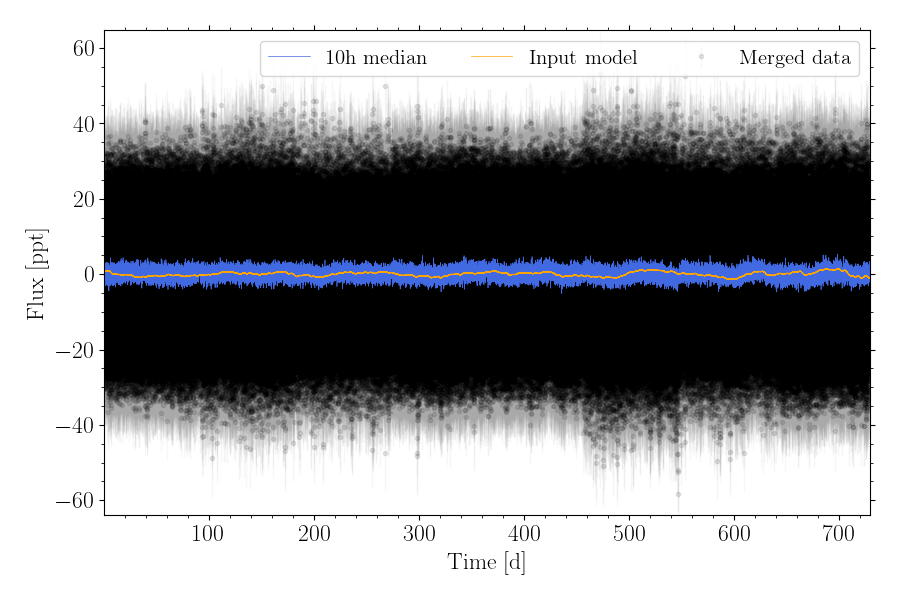

In [69]:
# Show result
lc.plot(input_model=True, flux_unit='ppt', flux_error=True, median_filter=10, alpha=0.1, figsize=(9,6));

---
## Final data products
---

<IPython.core.display.Javascript object>


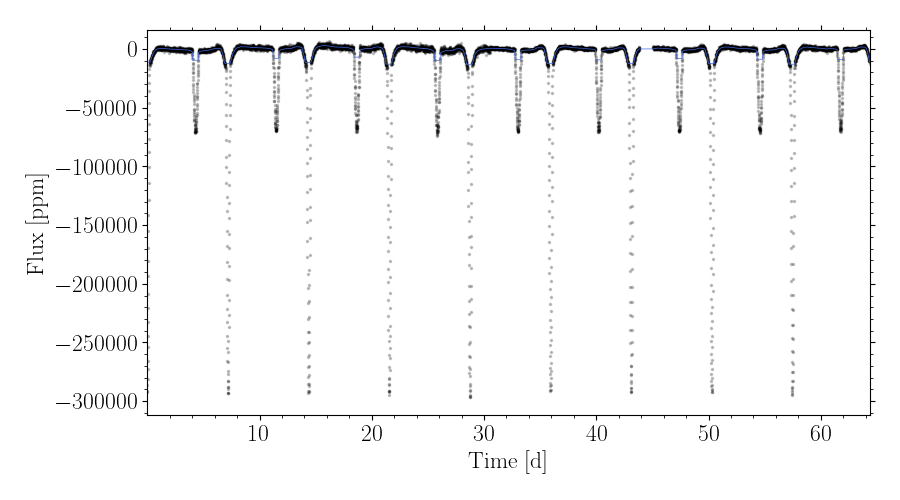

In [8]:
path = '/lhome/nicholas/software/workdir/cs-binary/finals'
star = 'mag085/lc_000000001.ftr'

# In multi mode we parse the entire directory of files
lc = LightCurve(f'{path}/{star}', mode="final")

# Introduce gaps from file
inputFileGap = '/lhome/nicholas/software/workdir/mocka/input/instrumentGAP.tab'
lc.gaps(inputFileGap, replace=True, plot=False);

# Show a quarter light curve
lc.plot(flux_unit='ppm', median_filter=1, input_model=True, legend=False, figsize=(9,5));

<IPython.core.display.Javascript object>


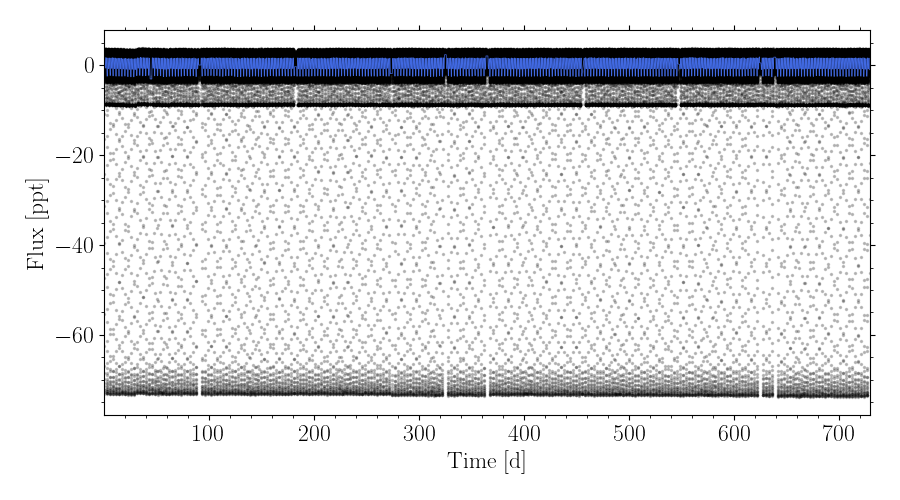

In [183]:
path = '/lhome/nicholas/software/workdir/cs-binary/finals'
star = 'mag085/lc_000000090.ftr'

# In multi mode we parse the entire directory of files
lc = LightCurve(f'{path}/{star}', mode="final")

# Introduce gaps from file
inputFileGap = '/lhome/nicholas/software/workdir/mocka/input/instrumentGAP.tab'
lc.gaps(inputFileGap, replace=True, plot=False);

# Show a quarter light curve
lc.plot(flux_unit='ppt', median_filter=1, input_model=False, legend=False, figsize=(9,5));